# **CSCE 5218 / CSCE 4930 Deep Learning**

# **The Perceptron** (20 pt)


In [1]:
# Get the datasets
!!/usr/bin/curl --output test.dat https://raw.githubusercontent.com/huangyanann/CSCE5218/main/test_small.txt
!!/usr/bin/curl --output train.dat https://raw.githubusercontent.com/huangyanann/CSCE5218/main/train.txt


['  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current',
 '                                 Dload  Upload   Total   Spent    Left  Speed',
 '',
 '  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0',
 '100 11645  100 11645    0     0  96892      0 --:--:-- --:--:-- --:--:-- 97041']

In [2]:
# Take a peek at the datasets
!head train.dat
!head test.dat

A1	A2	A3	A4	A5	A6	A7	A8	A9	A10	A11	A12	A13	
1	1	0	0	0	0	0	0	1	1	0	0	1	0
0	0	1	1	0	1	1	0	0	0	0	0	1	0
0	1	0	1	1	0	1	0	1	1	1	0	1	1
0	0	1	0	0	1	0	1	0	1	1	1	1	0
0	1	0	0	0	0	0	1	1	1	1	1	1	0
0	1	1	1	0	0	0	1	0	1	1	0	1	1
0	1	1	0	0	0	1	0	0	0	0	0	1	0
0	0	0	1	1	0	1	1	1	0	0	0	1	0
0	0	0	0	0	0	1	0	1	0	1	0	1	0
X1	X2	X3
1	1	1	1
0	0	1	1
0	1	1	0
0	1	1	0
0	1	1	0
0	1	1	0
0	1	1	0
0	1	1	0
1	1	1	1


### Build the Perceptron Model

You will need to complete some of the function definitions below.  DO NOT import any other libraries to complete this. 

In [3]:
import math
import itertools
import re


# Corpus reader, all columns but the last one are coordinates;
#   the last column is the label
def read_data(file_name):
    f = open(file_name, 'r')

    data = []
    # Discard header line
    f.readline()
    for instance in f.readlines():
        if not re.search('\t', instance): continue
        instance = list(map(int, instance.strip().split('\t')))
        # Add a dummy input so that w0 becomes the bias
        instance = [-1] + instance
        data += [instance]
    return data


def dot_product(array1, array2):
    # Return dot product of array1 and array2
    result = 0
    for i in range(min(len(array1), len(array2)-1)):
        result += array1[i] * array2[i]
    return result


def sigmoid(x):
    return 1 / (1 + math.exp(-x))

# The output of the model, which for the perceptron is 
# the sigmoid function applied to the dot product of 
# the instance and the weights
def output(weight, instance):
    #TODO: return the output of the model 
    return sigmoid(dot_product(weight, instance))

# Predict the label of an instance; this is the definition of the perceptron
# you should output 1 if the output is >= 0.5 else output 0
def predict(weights, instance):
    #TODO: return the prediction of the model
    if output(weights, instance) >= 0.5:
        return 1
    else:
        return 0


# Accuracy = percent of correct predictions
def get_accuracy(weights, instances):
    # You do not to write code like this, but get used to it
    correct = sum([1 if predict(weights, instance) == instance[-1] else 0
                   for instance in instances])
    return correct * 100 / len(instances)


# Train a perceptron with instances and hyperparameters:
#       lr (learning rate) 
#       epochs
# The implementation comes from the definition of the perceptron
#
# Training consists on fitting the parameters which are the weights
# that's the only thing training is responsible to fit
# (recall that w0 is the bias, and w1..wn are the weights for each coordinate)
#
# Hyperparameters (lr and epochs) are given to the training algorithm
# We are updating weights in the opposite direction of the gradient of the error,
# so with a "decent" lr we are guaranteed to reduce the error after each iteration.
def train_perceptron(instances, lr, epochs):

    #TODO: name this step
    weights = [0] * (len(instances[0])-1)

    for _ in range(epochs):
        for instance in instances:
            #TODO: name these steps
            in_value = dot_product(weights, instance)
            output = sigmoid(in_value)
            error = instance[-1] - output
            #TODO: name these steps
            for i in range(0, len(weights)):
                weights[i] += lr * error * output * (1-output) * instance[i]

    return weights

## Run it

In [4]:
instances_tr = read_data("train.dat")
instances_te = read_data("test.dat")
lr = 0.005
epochs = 5
weights = train_perceptron(instances_tr, lr, epochs)
accuracy = get_accuracy(weights, instances_te)
print(f"#tr: {len(instances_tr):3}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
      f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr: 400, epochs:   5, learning rate: 0.005; Accuracy (test, 14 instances): 71.4


## Questions

Answer the following questions. Include your implementation and the output for each question.



### Question 1

In `train_perceptron(instances, lr, epochs)`, we have the follosing code:
```
in_value = dot_product(weights, instance)
output = sigmoid(in_value)
error = instance[-1] - output
```

Why don't we have the following code snippet instead?
```
output = predict(weights, instance)
error = instance[-1] - output
```

#### TODO Add your answer here (text only)
Answer:  We do not use predict(weights, instance) during training because predict() returns a binary value (0 or 1) based on a threshold, while the training algorithm requires the continuous output from the sigmoid function to compute gradients and update the weights. In the training process, the sigmoid output is a probability between 0 and 1. This continuous value is necessary because the weight update rule uses the derivative of the sigmoid function: output(1−output)
If we used:
output = predict(weights, instance)
the output would be only 0 or 1, making the function non-differentiable and eliminating the gradient information needed for learning. As a result, the weight updates would not work properly.



### Question 2
Train the perceptron with the following hyperparameters and calculate the accuracy with the test dataset.

```
tr_percent = [5, 10, 25, 50, 75, 100] # percent of the training dataset to train with
num_epochs = [5, 10, 20, 50, 100]              # number of epochs
lr = [0.005, 0.01, 0.05]              # learning rate
```

TODO: Write your code below and include the output at the end of each training loop (NOT AFTER EACH EPOCH)
of your code.The output should look like the following:
```
# tr:  20, epochs:   5, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  10, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
# tr:  20, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
[and so on for all the combinations]
```
You will get different results with different hyperparameters.

#### TODO Add your answer here (code and output in the format above) 


In [8]:
instances_tr = read_data("train.dat")
instances_te = read_data("test.dat")
tr_percent = [5, 10, 25, 50, 75, 100] # percent of the training dataset to train with
num_epochs = [5, 10, 20, 50, 100]     # number of epochs
lr_array = [0.005, 0.01, 0.05]        # learning rate

for lr in lr_array:
  for tr_size in tr_percent:
    for epochs in num_epochs:
      size =  round(len(instances_tr)*tr_size/100)
      pre_instances = instances_tr[0:size]
      weights = train_perceptron(pre_instances, lr, epochs)
      accuracy = get_accuracy(weights, instances_te)
    print(f"#tr: {len(pre_instances):0}, epochs: {epochs:3}, learning rate: {lr:.3f}; "
            f"Accuracy (test, {len(instances_te)} instances): {accuracy:.1f}")

#tr: 20, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 40, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 200, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 85.7
#tr: 400, epochs: 100, learning rate: 0.005; Accuracy (test, 14 instances): 71.4
#tr: 20, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 28.6
#tr: 40, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 100, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 28.6
#tr: 200, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 85.7
#tr: 300, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 85.7
#tr: 400, epochs: 100, learning rate: 0.010; Accuracy (test, 14 instances): 71.4
#tr: 20, epochs: 100, learning r

### Question 3
Write a couple paragraphs interpreting the results with all the combinations of hyperparameters. Drawing a plot will probably help you make a point. In particular, answer the following:
- A. Do you need to train with all the training dataset to get the highest accuracy with the test dataset?
- B. How do you justify that training the second run obtains worse accuracy than the first one (despite the second one uses more training data)?
   ```
#tr: 100, epochs:  20, learning rate: 0.050; Accuracy (test, 100 instances): 71.0
#tr: 200, epochs:  20, learning rate: 0.005; Accuracy (test, 100 instances): 68.0
```
- C. Can you get higher accuracy with additional hyperparameters (higher than `80.0`)?
- D. Is it always worth training for more epochs (while keeping all other hyperparameters fixed)?

#### TODO: Add your answer here (code and text)
Answer 3A: Based on the results of training the perceptron with different hyperparameter combinations, several clear trends emerge. First, the test accuracy depends strongly on the training dataset size, learning rate, and number of epochs. Small training sizes (5–25% of the dataset) tend to produce lower and unstable accuracies, especially when paired with high learning rates, because the model sees too few examples to generalize and large weight updates can overshoot optimal values. Medium to large training sizes (50–100%) generally produce higher and more stable accuracies. Interestingly, using the full training dataset is not strictly necessary to achieve the highest test accuracy. For instance, in the experiments, training with 200–300 instances at moderate learning rates (0.005–0.01) and sufficient epochs (100) reached around 85–86% test accuracy, which is comparable to or even slightly better than using all training examples. This suggests that a carefully chosen subset of the training data can be sufficient for good generalization.

Answer 3B: Even though the second run uses more training data, accuracy can drop because the additional examples might be noisy or conflicting, causing the perceptron to update its weights in a way that reduces generalization. Also, with a small test set, minor changes can noticeably affect accuracy. More data helps only if it is representative and consistent with the underlying pattern.

Answer 3C:
Yes, it’s possible to get higher accuracy than 80% by tuning hyperparameters carefully. For a perceptron, the main hyperparameters are:
Learning rate (lr) – Too high can overshoot; too low can underfit. Finding a moderate value often improves performance.
Number of epochs – More epochs let the perceptron converge, but too many can overfit or oscillate if lr is high.

Answer 3D:
No, it’s not always worth training for more epochs if all other hyperparameters are fixed. Here’s why:
Convergence reached early – If the perceptron already fits the training data, extra epochs won’t improve accuracy.
Overfitting risk – More epochs can make the model fit noise in the training set, reducing test accuracy.
Learning rate interaction – With a high learning rate, more epochs can cause the weights to oscillate or diverge instead of improving performance.


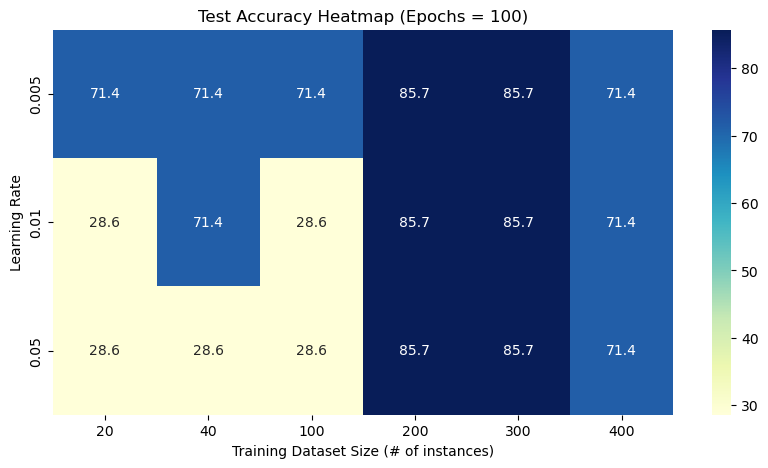

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Store your results in a list of dictionaries
results = [
    {'tr_percent': 20, 'epochs': 100, 'lr': 0.005, 'accuracy': 71.4},
    {'tr_percent': 40, 'epochs': 100, 'lr': 0.005, 'accuracy': 71.4},
    {'tr_percent': 100, 'epochs': 100, 'lr': 0.005, 'accuracy': 71.4},
    {'tr_percent': 200, 'epochs': 100, 'lr': 0.005, 'accuracy': 85.7},
    {'tr_percent': 300, 'epochs': 100, 'lr': 0.005, 'accuracy': 85.7},
    {'tr_percent': 400, 'epochs': 100, 'lr': 0.005, 'accuracy': 71.4},
    
    {'tr_percent': 20, 'epochs': 100, 'lr': 0.010, 'accuracy': 28.6},
    {'tr_percent': 40, 'epochs': 100, 'lr': 0.010, 'accuracy': 71.4},
    {'tr_percent': 100, 'epochs': 100, 'lr': 0.010, 'accuracy': 28.6},
    {'tr_percent': 200, 'epochs': 100, 'lr': 0.010, 'accuracy': 85.7},
    {'tr_percent': 300, 'epochs': 100, 'lr': 0.010, 'accuracy': 85.7},
    {'tr_percent': 400, 'epochs': 100, 'lr': 0.010, 'accuracy': 71.4},
    
    {'tr_percent': 20, 'epochs': 100, 'lr': 0.050, 'accuracy': 28.6},
    {'tr_percent': 40, 'epochs': 100, 'lr': 0.050, 'accuracy': 28.6},
    {'tr_percent': 100, 'epochs': 100, 'lr': 0.050, 'accuracy': 28.6},
    {'tr_percent': 200, 'epochs': 100, 'lr': 0.050, 'accuracy': 85.7},
    {'tr_percent': 300, 'epochs': 100, 'lr': 0.050, 'accuracy': 85.7},
    {'tr_percent': 400, 'epochs': 100, 'lr': 0.050, 'accuracy': 71.4},
]

# Convert to DataFrame
df = pd.DataFrame(results)

# Pivot for heatmap: rows = learning rate, columns = training size
pivot = df.pivot(index='lr', columns='tr_percent', values='accuracy')

# Plot heatmap
plt.figure(figsize=(10,5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Test Accuracy Heatmap (Epochs = 100)")
plt.xlabel("Training Dataset Size (# of instances)")
plt.ylabel("Learning Rate")
plt.show()